# EOSC 213 — Lecture 16 Coding Notebook
## Boundary Value Problems, Stiff ODE Systems, Newton's Method, and Implicit Methods

This notebook is designed for **live in-class coding** and should comfortably fill about **1 hour 10 minutes**.

### Topics
1. Boundary value problems (BVPs)  
2. Stiff ODE systems  
3. Newton's method  
4. Solving an implicit method using Newton iteration inside each time step  


In [1]:
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

## Part 1: A very simple BVP by finite differences

We consider the boundary value problem

$$
u''(x) = -1, \qquad x \in (0,1),
$$

with boundary conditions

$$
u(0)=0, \qquad u(1)=0.
$$

The exact solution is
$$
u(x)=\frac{1}{2}x(1-x).
$$

We will discretize the interval and approximate the second derivative using
$$
u''(x_i) \approx \frac{u_{i-1}-2u_i+u_{i+1}}{h^2}.
$$

This gives a linear system for the unknown interior values.

### Problem 1A
Create a grid on $[0,1]$ with `n = 6` intervals.

- Compute the grid spacing `h`
- Create the grid points `x`
- Identify the interior points

In [10]:
# TODO: set up the grid
n = 10
h = 1.0 / n
x = torch.linspace(0.0, 1.0, n + 1)
x_interior = x[1:-1]

print("h =", h)
print("grid points =", x)
print("interior points =", x_interior)

h = 0.1
grid points = tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])
interior points = tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000])


### Problem 1B
Build the matrix $A$ and right-hand side $b$ for the finite-difference system.

For each interior point,
$$
\frac{u_{i-1}-2u_i+u_{i+1}}{h^2} = -1.
$$

After multiplying by $h^2$,
$$
u_{i-1}-2u_i+u_{i+1} = -h^2.
$$

So the matrix has:
- `-2` on the diagonal
- `1` on the upper diagonal
- `1` on the lower diagonal

In [11]:
# TODO: build A and b
m = len(x_interior)   # number of interior unknowns

A = torch.zeros((m, m))
b = -h**2 * torch.ones(m)

for i in range(m):
    A[i, i] = -2.0
    if i > 0:
        A[i, i-1] = 1.0
    if i < m - 1:
        A[i, i+1] = 1.0

print("A =")
print(A)
print("b =")
print(b)

A =
tensor([[-2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 1., -2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  1., -2.,  1.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  1., -2.,  1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  1., -2.,  1.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  1., -2.,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  1., -2.,  1.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  1., -2.,  1.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., -2.]])
b =
tensor([-0.0100, -0.0100, -0.0100, -0.0100, -0.0100, -0.0100, -0.0100, -0.0100,
        -0.0100])


### Problem 1C
Solve the linear system for the interior values and then insert the boundary values.

- Solve `A u_interior = b`
- Build the full vector `u_num`
- Compare against the exact solution

In [12]:
# TODO: solve and reconstruct the full solution
u_interior = torch.linalg.solve(A, b)

u_num = torch.zeros(n + 1)
u_num[1:-1] = u_interior

u_exact = 0.5 * x * (1.0 - x)

print("numerical solution =", u_num)
print("exact solution     =", u_exact)

numerical solution = tensor([0.0000, 0.0450, 0.0800, 0.1050, 0.1200, 0.1250, 0.1200, 0.1050, 0.0800,
        0.0450, 0.0000])
exact solution     = tensor([0.0000, 0.0450, 0.0800, 0.1050, 0.1200, 0.1250, 0.1200, 0.1050, 0.0800,
        0.0450, 0.0000])


### Problem 1D
Plot the numerical and exact solutions on the same figure.

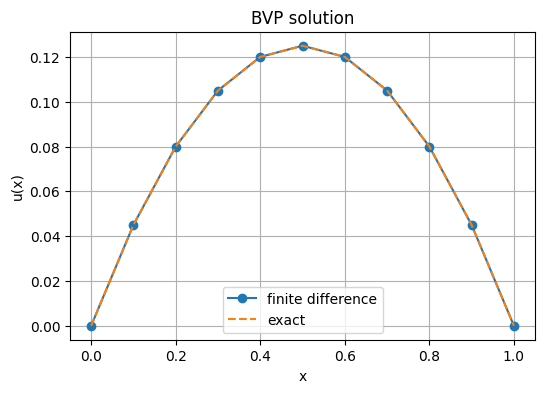

In [13]:
plt.figure(figsize=(6,4))
plt.plot(x, u_num, "o-", label="finite difference")
plt.plot(x, u_exact, "--", label="exact")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("BVP solution")
plt.legend()
plt.grid(True)
plt.show()

### Problem 1E
Compute the maximum absolute error.

In [14]:
error = torch.max(torch.abs(u_num - u_exact))
print("max error =", error.item())

max error = 4.163336342344337e-17


## Part 2: A very simple stiff ODE system

Now consider the system
$$
y_1' = -y_1, \qquad y_2' = -50 y_2,
$$
with initial condition
$$
y_1(0)=1, \qquad y_2(0)=1.
$$

This is a good toy example of stiffness because one component decays slowly and the other decays very quickly.

The exact solution is
$$
y_1(t)=e^{-t}, \qquad y_2(t)=e^{-50t}.
$$

### Problem 2A
Write a function `f(t, y)` for the system.

Use a length-2 tensor `y = [y1, y2]`.

In [16]:
def f_stiff(t, y):
    y1 = y[0]
    y2 = y[1]
    return torch.tensor([
        -y1,
        -50.0 * y2
    ])

### Problem 2B
Implement the **forward Euler** method for this system.

Use:
- final time `T = 1`
- number of steps `N = 20`

Store all solution values in a tensor.

In [17]:
T = 1.0
N = 20
dt = T / N

t = torch.linspace(0.0, T, N + 1)
y = torch.zeros((N + 1, 2))
y[0] = torch.tensor([1.0, 1.0])

for n in range(N):
    y[n+1] = y[n] + dt * f_stiff(t[n], y[n])

print(y[:5])
print("last value =", y[-1])

tensor([[ 1.0000,  1.0000],
        [ 0.9500, -1.5000],
        [ 0.9025,  2.2500],
        [ 0.8574, -3.3750],
        [ 0.8145,  5.0625]])
last value = tensor([3.5849e-01, 3.3253e+03])


### Problem 2C
Compute the exact solution and plot both components.

This will let us compare the forward Euler solution against the exact solution.

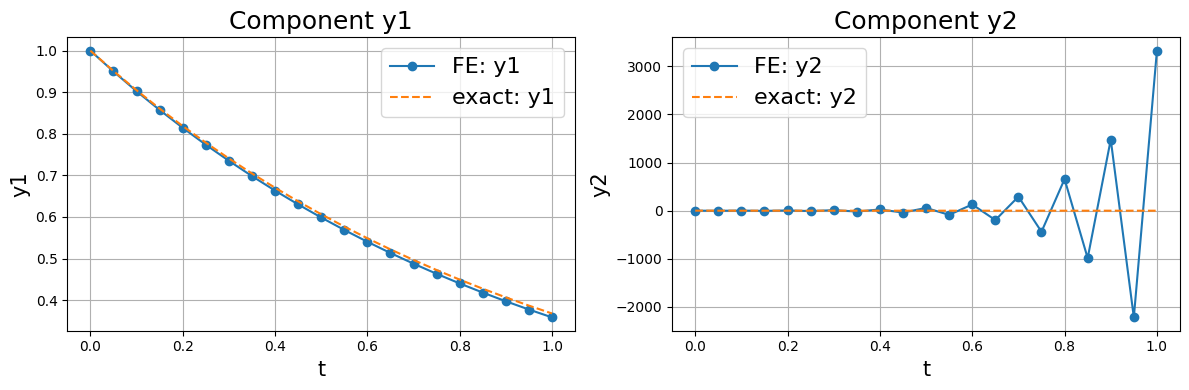

In [24]:
y_exact = torch.zeros((N + 1, 2))
y_exact[:, 0] = torch.exp(-t)
y_exact[:, 1] = torch.exp(-50.0 * t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t, y[:,0], "o-", label="FE: y1")
ax1.plot(t, y_exact[:,0], "--", label="exact: y1")
ax1.set_xlabel("t", fontsize=15)
ax1.set_ylabel("y1", fontsize=15)
ax1.set_title("Component y1", fontsize=18)
ax1.legend(fontsize=16)
ax1.grid(True)

ax2.plot(t, y[:,1], "o-", label="FE: y2")
ax2.plot(t, y_exact[:,1], "--", label="exact: y2")
ax2.set_xlabel("t", fontsize=15)
ax2.set_ylabel("y2", fontsize=15)
ax2.set_title("Component y2", fontsize=18)
ax2.legend(fontsize=16)
ax2.grid(True)

plt.tight_layout()
plt.show()

### Problem 2D
Now repeat forward Euler with a much smaller time step.

Use `N = 200` and compare what changes.

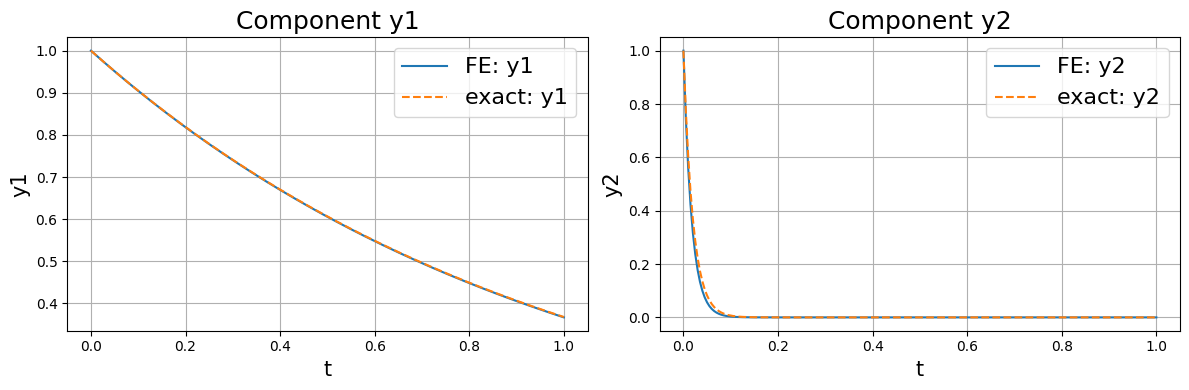

In [27]:
T_small = 1.0
N_small = 200
dt_small = T_small / N_small

t_small = torch.linspace(0.0, T_small, N_small + 1)
y_small = torch.zeros((N_small + 1, 2))
y_small[0] = torch.tensor([1.0, 1.0])

for n in range(N_small):
    y_small[n+1] = y_small[n] + dt_small * f_stiff(t_small[n], y_small[n])

y_exact_small = torch.zeros((N_small + 1, 2))
y_exact_small[:, 0] = torch.exp(-t_small)
y_exact_small[:, 1] = torch.exp(-50.0 * t_small)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t_small, y_small[:,0], label="FE: y1")
ax1.plot(t_small, y_exact_small[:,0], "--", label="exact: y1")
ax1.set_xlabel("t", fontsize=15)
ax1.set_ylabel("y1", fontsize=15)
ax1.set_title("Component y1", fontsize=18)
ax1.legend(fontsize=16)
ax1.grid(True)

ax2.plot(t_small, y_small[:,1], label="FE: y2")
ax2.plot(t_small, y_exact_small[:,1], "--", label="exact: y2")
ax2.set_xlabel("t", fontsize=15)
ax2.set_ylabel("y2", fontsize=15)
ax2.set_title("Component y2", fontsize=18)
ax2.legend(fontsize=16)
ax2.grid(True)

plt.tight_layout()
plt.show()


### Discussion
With a stiff problem, explicit methods may require **very small** time steps for stability, even when the true solution is smooth.

That is one reason implicit methods are useful.

## Part 3: Newton's method for a scalar nonlinear equation

We now solve
$$
g(x) = x^2 - 2 = 0.
$$

The root is $x=\sqrt{2}$.

Newton's iteration is
$$
x_{k+1} = x_k - \frac{g(x_k)}{g'(x_k)}.
$$

### Problem 3A
Define the function `g(x)` and its derivative `dg(x)`.

In [29]:
def g(x):
    return x**2 - 2.0

def dg(x):
    return 2.0 * x

### Problem 3B
Run Newton's method starting from `x0 = 1.0` for 5 iterations.

Store the iterates in a Python list and print them.

In [30]:
xk = torch.tensor(1.0)
iters = [xk.item()]

for k in range(5):
    xk = xk - g(xk) / dg(xk)
    iters.append(xk.item())

print("Newton iterates:")
for k, val in enumerate(iters):
    print(f"k = {k}, x = {val}")

Newton iterates:
k = 0, x = 1.0
k = 1, x = 1.5
k = 2, x = 1.4166666666666667
k = 3, x = 1.4142156862745099
k = 4, x = 1.4142135623746899
k = 5, x = 1.4142135623730951


### Problem 3C
Compare the final iterate to `torch.sqrt(torch.tensor(2.0))`.

In [31]:
true_root = torch.sqrt(torch.tensor(2.0))
print("Newton approximation =", xk.item())
print("true root            =", true_root.item())
print("absolute error       =", torch.abs(xk - true_root).item())

Newton approximation = 1.4142135623730951
true root            = 1.4142135623730951
absolute error       = 0.0


### Problem 3D
Try a different nonlinear equation:
$$
g(x)=x^3-2.
$$

Update the code below and run Newton again.

In [32]:
def g2(x):
    return x**3 - 2.0

def dg2(x):
    return 3.0 * x**2

xk = torch.tensor(1.0)
iters2 = [xk.item()]

for k in range(6):
    xk = xk - g2(xk) / dg2(xk)
    iters2.append(xk.item())

print("Newton iterates for x^3 - 2 = 0:")
for k, val in enumerate(iters2):
    print(f"k = {k}, x = {val}")

Newton iterates for x^3 - 2 = 0:
k = 0, x = 1.0
k = 1, x = 1.3333333333333333
k = 2, x = 1.2638888888888888
k = 3, x = 1.259933493449977
k = 4, x = 1.2599210500177698
k = 5, x = 1.2599210498948732
k = 6, x = 1.2599210498948732


## Part 4: Backward Euler solved using Newton iteration at each step

Now we combine the ideas of:
- implicit time stepping
- Newton's method

Consider the scalar ODE
$$
y' = -10 y^2, \qquad y(0)=1.
$$

Backward Euler gives
$$
y_{n+1} = y_n + \Delta t \, (-10 y_{n+1}^2).
$$

So $y_{n+1}$ must satisfy the nonlinear equation
$$
F(z) = z - y_n + 10 \Delta t \, z^2 = 0,
$$
where $z = y_{n+1}$.

We solve this nonlinear equation by Newton's method at every time step.

### Problem 4A
Write the functions `F(z, y_old, dt)` and `dF(z, dt)`.

In [33]:
def F(z, y_old, dt):
    return z - y_old + 10.0 * dt * z**2

def dF(z, dt):
    return 1.0 + 20.0 * dt * z

### Problem 4B
For one backward Euler step, solve for `y_next` using Newton's method.

Take:
- `y_old = 1.0`
- `dt = 0.1`
- initial guess `z0 = y_old`

Run 5 Newton iterations.

In [34]:
y_old = torch.tensor(1.0)
dt = 0.1

z = y_old.clone()

for k in range(5):
    z = z - F(z, y_old, dt) / dF(z, dt)
    print(f"Newton step {k+1}: z = {z.item()}")

y_next = z
print("computed y_next =", y_next.item())

Newton step 1: z = 0.6666666666666667
Newton step 2: z = 0.6190476190476191
Newton step 3: z = 0.6180344478216818
Newton step 4: z = 0.618033988749989
Newton step 5: z = 0.6180339887498948
computed y_next = 0.6180339887498948


### Problem 4C
Now place that Newton solve **inside a time-stepping loop**.

Use:
- `T = 1`
- `N = 10`
- Newton iterations per step = 5

In [35]:
T = 1.0
N = 10
dt = T / N

t_be = torch.linspace(0.0, T, N + 1)
y_be = torch.zeros(N + 1)
y_be[0] = 1.0

for n in range(N):
    y_old = y_be[n]
    z = y_old.clone()   # initial guess for Newton

    for k in range(5):
        z = z - F(z, y_old, dt) / dF(z, dt)

    y_be[n+1] = z

print(y_be)

tensor([1.0000, 0.6180, 0.4317, 0.3256, 0.2587, 0.2132, 0.1806, 0.1562, 0.1373,
        0.1224, 0.1102])


### Problem 4D
Compare backward Euler against forward Euler for the same ODE
$$
y'=-10y^2.
$$

Implement forward Euler with the same time step and plot both.

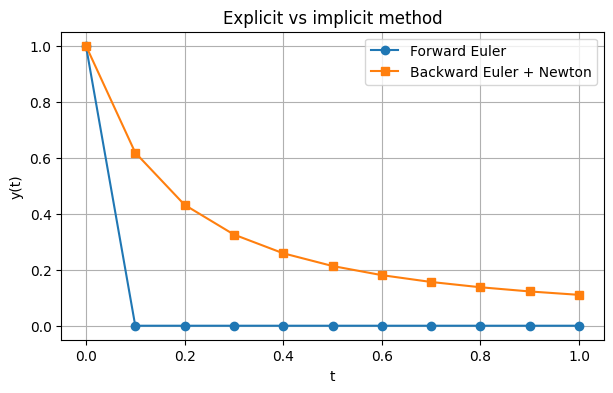

In [39]:
def f_scalar(t, y):
    return -10.0 * y**2

y_fe = torch.zeros(N + 1)
y_fe[0] = 1.0

for n in range(N):
    y_fe[n+1] = y_fe[n] + dt * f_scalar(t_be[n], y_fe[n])

plt.figure(figsize=(7,4))
plt.plot(t_be, y_fe, "o-", label="Forward Euler")
plt.plot(t_be, y_be, "s-", label="Backward Euler + Newton")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Explicit vs implicit method")
plt.legend()
plt.grid(True)
plt.show()

### Problem 4E
The exact solution of
$$
y'=-10y^2, \qquad y(0)=1
$$
is
$$
y(t)=\frac{1}{1+10t}.
$$

Plot the exact solution together with both numerical solutions.

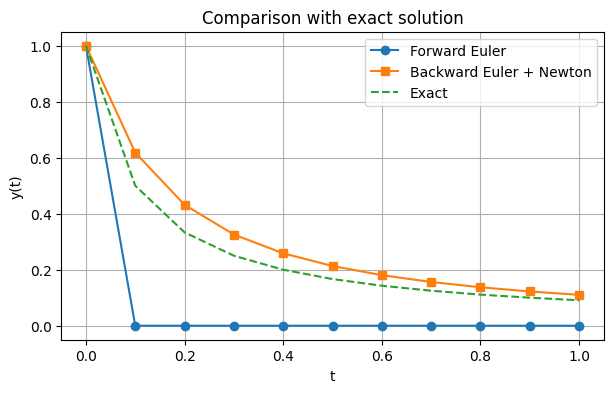

In [40]:
y_exact_be = 1.0 / (1.0 + 10.0 * t_be)

plt.figure(figsize=(7,4))
plt.plot(t_be, y_fe, "o-", label="Forward Euler")
plt.plot(t_be, y_be, "s-", label="Backward Euler + Newton")
plt.plot(t_be, y_exact_be, "--", label="Exact")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Comparison with exact solution")
plt.legend()
plt.grid(True)
plt.show()

## Optional wrap-up question

Try changing:
- the time step `dt`
- the number of Newton iterations
- the initial guess for Newton

and observe what happens.

This is the main idea:
- **BVPs** can become linear systems after discretization
- **stiff ODEs** can be hard for explicit methods
- **Newton's method** solves nonlinear equations
- **implicit methods** often require solving a nonlinear equation at each time step